# Taller 2: ¿Puedes Predecir el Fútbol Mejor que las Casas de Apuestas?
**Machine Learning I (ML1-2026I) — Universidad Externado de Colombia**
Daniela González · Belén Dueñas

---
**Pipeline:** Carga → EDA → Feature Engineering → Verificación de Supuestos → Modelos → Comparación vs Bet365

> *"El fútbol es un juego simple complicado por los que intentan hacerlo complejo."* — Johan Cruyff
> *"El Machine Learning es un juego complejo simplificado por los que entienden sus datos."* — ML1-2026I


## 1. Carga de Datos

Se utilizan tres fuentes del API exclusivo del curso. Se descargan los datos completos y se calcula las probabilidades implícitas de las cuotas eliminando el margen de la casa de apuestas.

In [ ]:
import pandas as pd
import numpy as np
import requests
import warnings
warnings.filterwarnings('ignore')

BASE = "https://premier.72-60-245-2.sslip.io"

matches = pd.read_csv(f"{BASE}/export/matches")
players = pd.read_csv(f"{BASE}/export/players")
shots_data = requests.get(f"{BASE}/events?is_shot=true&limit=10000").json()
shots = pd.DataFrame(shots_data['events'])

# Fechas en formato DD/MM/YYYY segun documentacion del API
matches['date'] = pd.to_datetime(matches['date'], format='%d/%m/%Y', errors='coerce')
matches['total_goals'] = matches['fthg'] + matches['ftag']

# Probabilidades implicitas: 1/cuota normalizada (elimina margen de la casa)
# Ejemplo: cuota 2.0 → prob bruta 50%, pero sumadas 3 cuotas dan >100%
# Normalizando eliminamos ese exceso (margen de ~5-8%)
for prefix in ['b365', 'bw', 'max', 'avg']:
    cols = [f'{prefix}h', f'{prefix}d', f'{prefix}a']
    if all(c in matches.columns for c in cols):
        inv = matches[cols].apply(lambda x: 1/x)
        total = inv.sum(axis=1)
        matches[f'implied_prob_h_{prefix}'] = inv[cols[0]] / total
        matches[f'implied_prob_d_{prefix}'] = inv[cols[1]] / total
        matches[f'implied_prob_a_{prefix}'] = inv[cols[2]] / total

matches['implied_prob_h'] = matches['implied_prob_h_b365']
matches['implied_prob_d'] = matches['implied_prob_d_b365']
matches['implied_prob_a'] = matches['implied_prob_a_b365']

print(f"Shots:   {shots.shape[0]:,} tiros")
print(f"Matches: {matches.shape[0]:,} partidos")
print(f"Players: {players.shape[0]:,} jugadores")


Shots:   7,198 tiros
Matches: 291 partidos
Players: 822 jugadores


## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 EDA de Tiros — Dataset del Modelo xG

**Pregunta guía:** ¿Qué variables tienen relación con que un tiro termine en gol?
Antes de construir features, exploramos los datos para que cada decisión de modelado tenga justificación estadística.


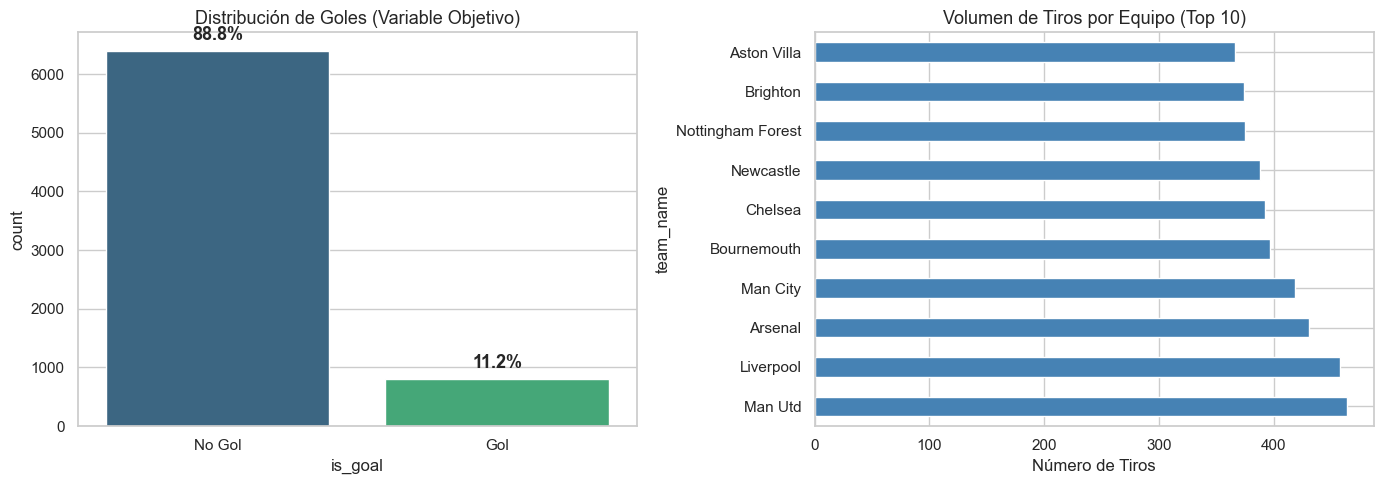

Total tiros: 7,198
Goles: 807 (11.2%)
Desbalance: 7.9:1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# 1. DESBALANCE DE CLASES
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cnt = sns.countplot(data=shots, x='is_goal', palette='viridis', ax=ax)
ax.set_title('Distribución de Goles (Variable Objetivo)', fontsize=13)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Gol', 'Gol'])
total = len(shots)
for p in cnt.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold',
                xytext=(0,5), textcoords='offset points')

top_teams = shots.groupby('team_name')['is_goal'].agg(['count','mean']).nlargest(10,'count')
top_teams['count'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Volumen de Tiros por Equipo (Top 10)', fontsize=13)
axes[1].set_xlabel('Número de Tiros')

plt.tight_layout()
plt.show()

print(f"Total tiros: {len(shots):,}")
print(f"Goles: {shots['is_goal'].sum():,} ({shots['is_goal'].mean()*100:.1f}%)")
print(f"Desbalance: {(shots['is_goal']==0).sum() / shots['is_goal'].sum():.1f}:1")


**Insights:**
- Solo el **11.2%** de los tiros terminan en gol — desbalance **8:1**.
- Un modelo naive que siempre prediga "No Gol" alcanza 88.8% de accuracy pero **nunca detecta un gol real**.
- **Implicación metodológica:** el accuracy no es una métrica útil aquí. Se usará **AUC-ROC, Precision y Recall** como métricas principales, y se aplicará `class_weight='balanced'` en los modelos de ensamble.


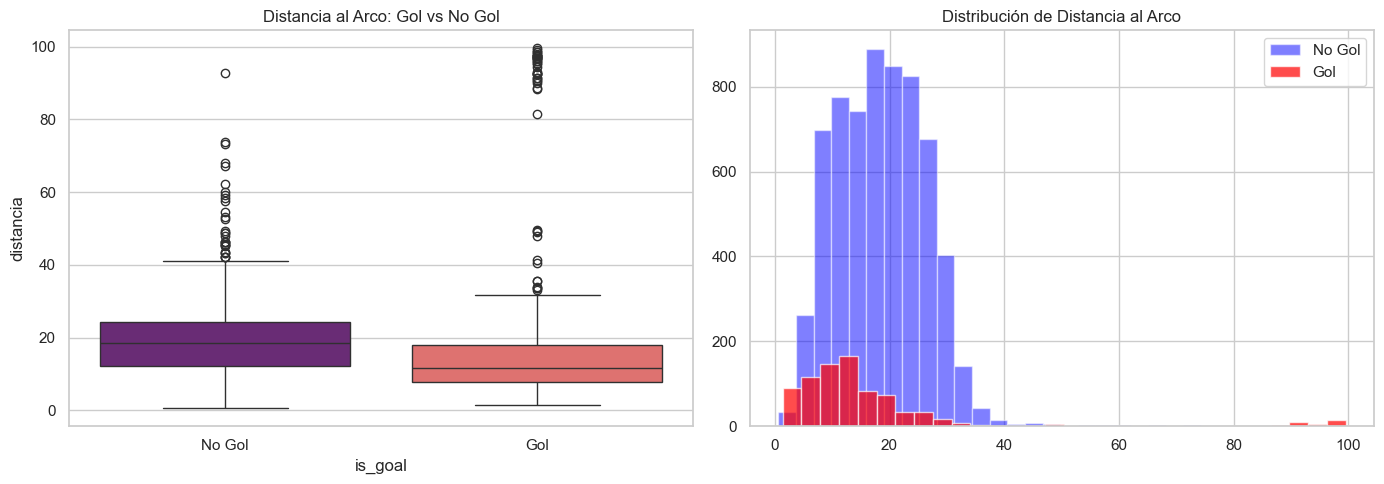

Mediana distancia Goles:    11.5
Mediana distancia No Goles: 18.4


In [ ]:
# 2. DISTANCIA AL ARCO
shots['distancia'] = np.sqrt((100 - shots['x'])**2 + (50 - shots['y'])**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=shots, x='is_goal', y='distancia', palette='magma', ax=axes[0])
axes[0].set_title('Distancia al Arco: Gol vs No Gol')
axes[0].set_xticklabels(['No Gol', 'Gol'])

shots[shots['is_goal']==0]['distancia'].hist(bins=30, alpha=0.5, label='No Gol', ax=axes[1], color='blue')
shots[shots['is_goal']==1]['distancia'].hist(bins=30, alpha=0.7, label='Gol', ax=axes[1], color='red')
axes[1].set_title('Distribución de Distancia al Arco')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Mediana distancia Goles:    {shots[shots['is_goal']==1]['distancia'].median():.1f}")
print(f"Mediana distancia No Goles: {shots[shots['is_goal']==0]['distancia'].median():.1f}")


**Insights:**
- Mediana de distancia para goles (~12 unidades) vs no goles (~19 unidades).
- Los goles se concentran en el área chica y borde del área grande.
- **Nota importante:** la distancia presenta multicolinealidad con el ángulo (VIF~5.5 vs 5.8), lo que se verificará formalmente en la sección de supuestos y determinará cuál conservar.


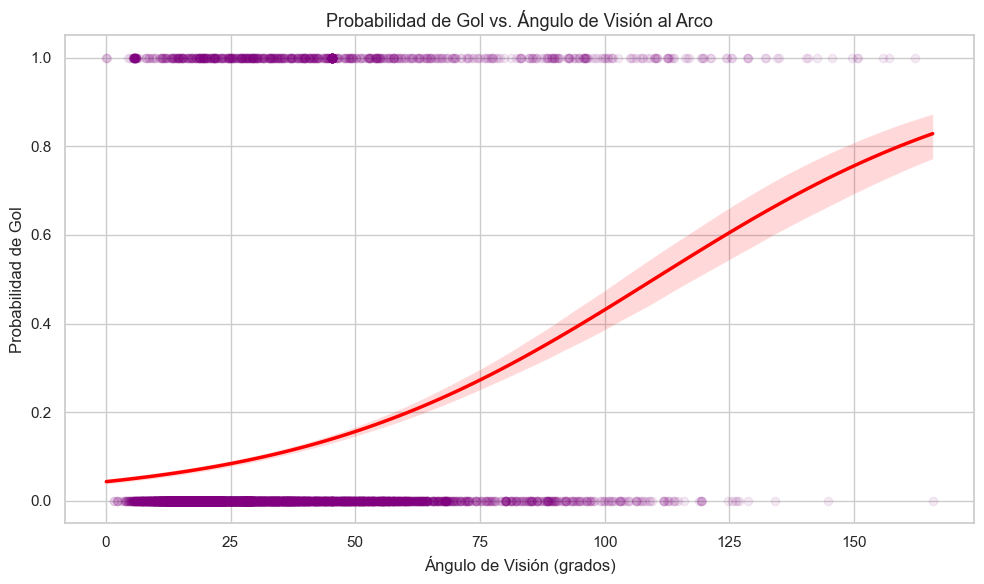

In [ ]:
# 3. ANGULO DE VISION AL ARCO
def calcular_angulo(row):
    a = np.sqrt((100 - row['x'])**2 + (45.2 - row['y'])**2)
    b = np.sqrt((100 - row['x'])**2 + (54.8 - row['y'])**2)
    c = 9.6
    return np.degrees(np.arccos(np.clip((a**2 + b**2 - c**2) / (2*a*b), -1, 1)))

shots['angulo'] = shots.apply(calcular_angulo, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=shots, x='angulo', y='is_goal', scatter_kws={'alpha': 0.08},
            logistic=True, color='purple', line_kws={'color': 'red', 'linewidth': 2.5}, ax=ax)
ax.set_title('Probabilidad de Gol vs. Ángulo de Visión al Arco', fontsize=13)
ax.set_xlabel('Ángulo de Visión (grados)')
ax.set_ylabel('Probabilidad de Gol')
plt.tight_layout()
plt.show()


**Insights:**
- La curva sigmoidea confirma que el ángulo es un **predictor no lineal crítico**.
- Ángulos < 10° (costados): probabilidad casi nula. Ángulos > 30°: probabilidad alta.
- **Implicación clave:** la relación **no es lineal en el log-odds**, lo que viola el supuesto de la regresión logística. Esto se verificará formalmente con el **test de Box-Tidwell** y justificará la discretización del ángulo en zonas tácticas.


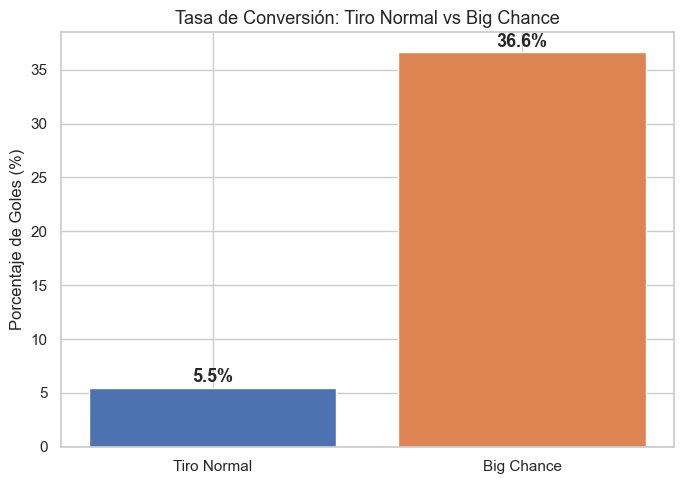

Ratio Big Chance vs Normal: 6.7x mayor


In [ ]:
# 4. BIG CHANCE: poder predictivo
shots['is_big_chance'] = shots['qualifiers'].astype(str).str.contains('BigChance', na=False, regex=False).astype(int)
conversion_bc = shots.groupby('is_big_chance')['is_goal'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Tiro Normal', 'Big Chance'], conversion_bc.values, color=['#4C72B0', '#DD8452'])
ax.set_title('Tasa de Conversión: Tiro Normal vs Big Chance', fontsize=13)
ax.set_ylabel('Porcentaje de Goles (%)')
for bar, val in zip(bars, conversion_bc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Ratio Big Chance vs Normal: {conversion_bc[1]/conversion_bc[0]:.1f}x mayor")


**Insights:**
- Un **Big Chance** tiene ~7x mayor probabilidad de gol (36.6% vs 5.5%).
- Es el **predictor individual más fuerte** del dataset con Information Gain = 0.055.
- **Extracción correcta:** se busca por nombre `'BigChance'` en el campo `qualifiers` (búsqueda por ID numérico produce resultados incorrectos).


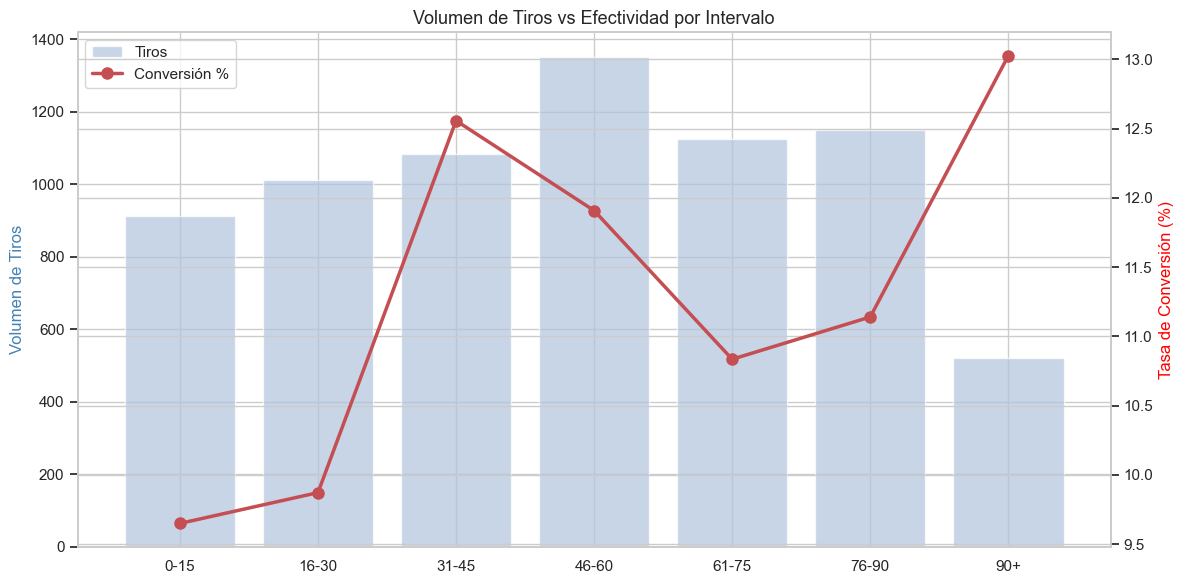

In [ ]:
# 5. EFECTIVIDAD POR INTERVALO DE TIEMPO
bins = [0, 15, 30, 45, 60, 75, 90, 105]
labels = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90', '90+']
shots['intervalo'] = pd.cut(shots['minute'], bins=bins, labels=labels)
stats_tiempo = shots.groupby('intervalo', observed=True)['is_goal'].agg(['mean', 'count'])
stats_tiempo['mean'] *= 100

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(stats_tiempo.index, stats_tiempo['count'], color='lightsteelblue', alpha=0.7, label='Tiros')
ax1.set_ylabel('Volumen de Tiros', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(stats_tiempo.index, stats_tiempo['mean'], 'ro-', linewidth=2.5, markersize=8, label='Conversión %')
ax2.set_ylabel('Tasa de Conversión (%)', color='red')
ax1.set_title('Volumen de Tiros vs Efectividad por Intervalo', fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.show()


**Insights:**
- El intervalo **90+** tiene el menor volumen pero la mayor tasa de conversión (>13%) — fatiga defensiva.
- **Implicación:** `is_final_minutes` (minuto > 85) captura este fenómeno como feature binaria. Se justifica su inclusión en el modelo a pesar de tener Mutual Information baja (0.0015).


### 2.2 EDA de Partidos — Dataset del Modelo 2

**Pregunta guía:** ¿Qué determina cuántos goles hay en un partido y quién gana?

La respuesta tiene dos componentes (principio de Dixon & Coles, 1997):
1. **Equipos que atacan bien** → historial ofensivo reciente
2. **Equipos que defienden mal** → historial defensivo reciente

Esto justifica construir features de **promedios móviles** en lugar de usar solo las odds H/D/A, que están diseñadas para predecir el resultado, no la cantidad de goles.


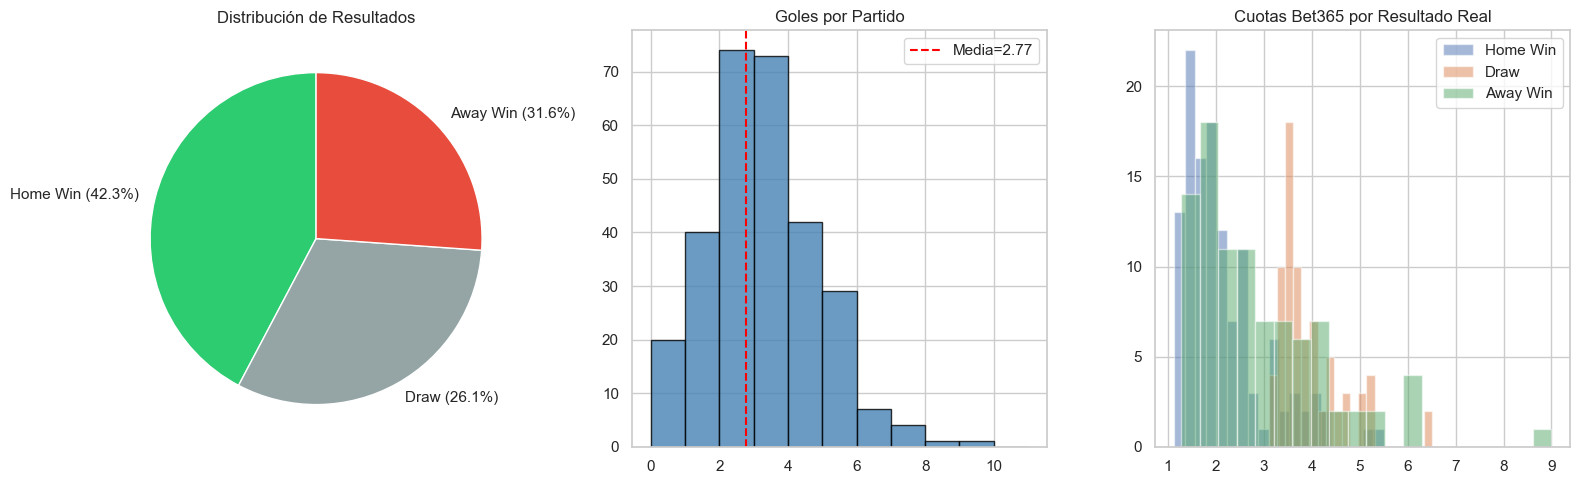

Media goles/partido: 2.77
Over 2.5 goles: 54.0%


In [ ]:
# Distribución de resultados y goles
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

result_counts = matches['ftr'].value_counts()
pct_h = result_counts.get('H', 0)/len(matches)*100
pct_d = result_counts.get('D', 0)/len(matches)*100
pct_a = result_counts.get('A', 0)/len(matches)*100

axes[0].pie(result_counts.values,
            labels=[f'Home Win ({pct_h:.1f}%)', f'Draw ({pct_d:.1f}%)', f'Away Win ({pct_a:.1f}%)'],
            colors=['#2ecc71','#95a5a6','#e74c3c'], startangle=90)
axes[0].set_title('Distribución de Resultados')

axes[1].hist(matches['total_goals'], bins=range(0, 12), edgecolor='black', color='steelblue', alpha=0.8)
axes[1].axvline(matches['total_goals'].mean(), color='red', linestyle='--',
                label=f'Media={matches["total_goals"].mean():.2f}')
axes[1].set_title('Goles por Partido')
axes[1].legend()

for res, col, label in [('H','b365h','Home Win'), ('D','b365d','Draw'), ('A','b365a','Away Win')]:
    axes[2].hist(matches[matches['ftr']==res][col].dropna(), bins=20, alpha=0.5, label=label)
axes[2].set_title('Cuotas Bet365 por Resultado Real')
axes[2].legend()

plt.tight_layout()
plt.show()
print(f"Media goles/partido: {matches['total_goals'].mean():.2f}")
print(f"Over 2.5 goles: {(matches['total_goals']>2.5).mean()*100:.1f}%")


**Insights:**
- Local gana el **42.3%** de los partidos. Los **empates (26.1%)** son el resultado de mayor entropía.
- Media de **2.77 goles/partido** con distribución sesgada a la derecha — viola el supuesto de normalidad de la regresión lineal (inherente al fenómeno, no un error del modelo).
- Las odds de Bet365 codifican expectativas de **quién gana**, no de **cuántos goles habrá**. Por esto el modelo de goles totales usa historial de goles como features principales.


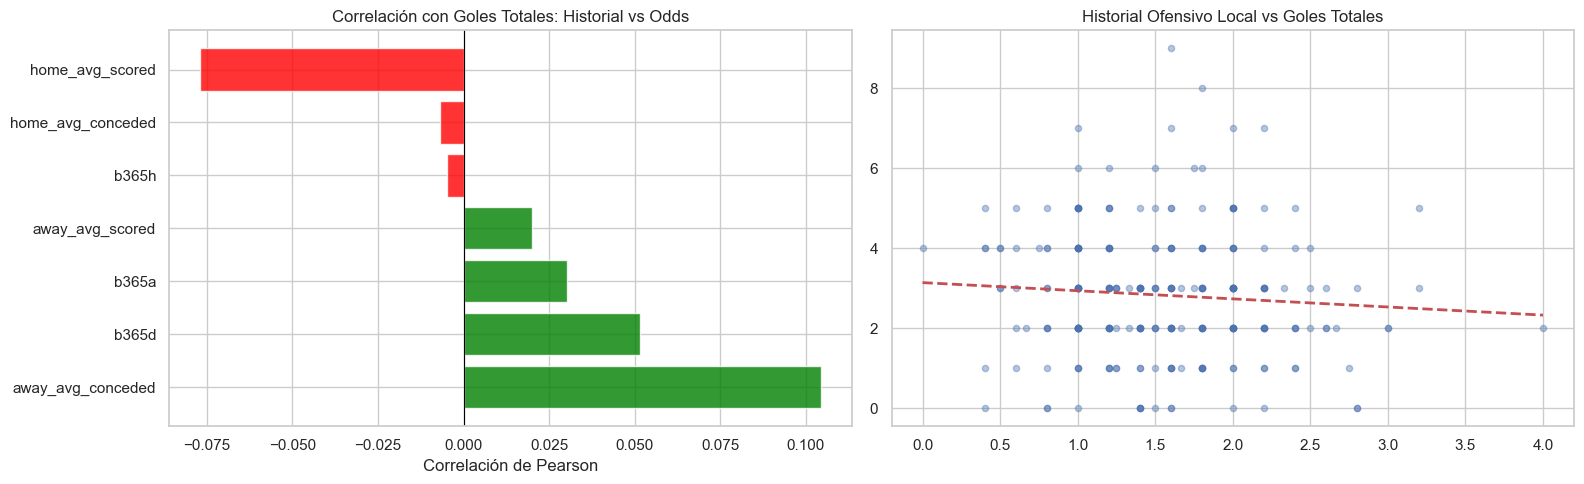

Correlaciones con total_goals:
away_avg_conceded    0.1043
b365d                0.0515
b365a                0.0302
away_avg_scored      0.0199
b365h               -0.0049
home_avg_conceded   -0.0069
home_avg_scored     -0.0769
Name: total_goals, dtype: float64


In [ ]:
# EDA historial de goles: ¿el pasado predice el futuro?
matches_sorted = matches.sort_values('date').copy()

for team_col, goals_col, new_col in [
    ('home_team', 'fthg', 'home_avg_scored'),
    ('home_team', 'ftag', 'home_avg_conceded'),
    ('away_team', 'ftag', 'away_avg_scored'),
    ('away_team', 'fthg', 'away_avg_conceded'),
]:
    matches_sorted[new_col] = (
        matches_sorted.groupby(team_col)[goals_col]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=2).mean())
    )

# Correlacion con goles totales
corr_features = ['total_goals', 'home_avg_scored', 'home_avg_conceded',
                 'away_avg_scored', 'away_avg_conceded', 'b365h', 'b365d', 'b365a']
corr_data = matches_sorted[corr_features].dropna()
corr_goals = corr_data.corr()['total_goals'].drop('total_goals').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_bar = ['green' if v > 0 else 'red' for v in corr_goals.values]
axes[0].barh(corr_goals.index, corr_goals.values, color=colors_bar, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlación con Goles Totales: Historial vs Odds')
axes[0].set_xlabel('Correlación de Pearson')

mask = matches_sorted[['home_avg_scored','total_goals']].dropna()
axes[1].scatter(mask['home_avg_scored'], mask['total_goals'], alpha=0.4, s=20)
z = np.polyfit(mask['home_avg_scored'], mask['total_goals'], 1)
x_line = np.linspace(mask['home_avg_scored'].min(), mask['home_avg_scored'].max(), 100)
axes[1].plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=2)
axes[1].set_title('Historial Ofensivo Local vs Goles Totales')

plt.tight_layout()
plt.show()

print("Correlaciones con total_goals:")
print(corr_goals.round(4))


**Insights — Justificación de features para Modelo 2:**
- Las variables de **historial reciente** (`home_avg_scored`, `away_avg_conceded`) tienen **mayor correlación** con goles totales que las odds H/D/A.
- Las odds de Bet365 codifican expectativas de resultado, no de goles — por eso el modelo con solo odds produce **R² negativo**.
- El **`shift(1)`** en los promedios móviles es crítico para evitar **data leakage**: solo se usa información de partidos anteriores al que se predice.
- Se usa ventana de **5 jornadas** (forma reciente) en lugar de toda la temporada, siguiendo el estándar de football analytics.


## 3. Feature Engineering

### 3.1 Features para el Modelo xG

Las features se organizan en tres dimensiones identificadas en el EDA:
1. **Geometría:** ángulo de visión (reemplaza a distancia tras análisis VIF)
2. **Contexto táctico:** Big Chance, penal, contraataque
3. **Técnica:** primer toque, cabezazo

**Nota crítica sobre extracción de qualifiers:** se busca por **nombre** (`'BigChance'`) en el campo `qualifiers`, no por ID numérico. La búsqueda por ID producía features incorrectas con valor 0 en todos los casos.


In [ ]:
def shot_feature_engineering(df):
    df_feat = df.copy()

    # Geometría
    df_feat['distancia'] = np.sqrt((100 - df_feat['x'])**2 + (50 - df_feat['y'])**2)

    def _angulo(row):
        a = np.sqrt((100 - row['x'])**2 + (45.2 - row['y'])**2)
        b = np.sqrt((100 - row['x'])**2 + (54.8 - row['y'])**2)
        c = 9.6
        return np.arccos(np.clip((a**2 + b**2 - c**2) / (2*a*b), -1, 1))

    df_feat['angulo_rad'] = df_feat.apply(_angulo, axis=1)
    df_feat['y_centrado'] = abs(df_feat['y'] - 50)
    df_feat['en_area_grande'] = (df_feat['x'] >= 83).astype(int)
    df_feat['en_area_chica'] = (df_feat['x'] >= 94).astype(int)

    # Qualifiers — búsqueda por NOMBRE (correcto)
    q = df_feat['qualifiers'].astype(str)
    df_feat['is_big_chance'] = q.str.contains('BigChance',  na=False, regex=False).astype(int)
    df_feat['is_header']     = q.str.contains('Head',       na=False, regex=False).astype(int)
    df_feat['is_penalty']    = q.str.contains('Penalty',    na=False, regex=False).astype(int)
    df_feat['is_fast_break'] = q.str.contains('FastBreak',  na=False, regex=False).astype(int)
    df_feat['first_touch']   = q.str.contains('FirstTouch', na=False, regex=False).astype(int)
    df_feat['is_set_piece']  = q.str.contains('SetPiece',   na=False, regex=False).astype(int)

    # Factor temporal
    df_feat['is_final_minutes'] = (df_feat['minute'] > 85).astype(int)

    if 'goal_mouth_z' in df_feat.columns:
        df_feat['goal_mouth_z'] = pd.to_numeric(df_feat['goal_mouth_z'], errors='coerce')
        df_feat['goal_mouth_z'] = df_feat['goal_mouth_z'].fillna(df_feat['goal_mouth_z'].median())

    return df_feat

shots_final = shot_feature_engineering(shots)

# Verificar conteos — confirmar que la extracción es correcta
print("--- VERIFICACIÓN DE QUALIFIERS ---")
for col, buscar in [('is_big_chance','BigChance'), ('is_header','Head'),
                    ('is_penalty','Penalty'), ('is_fast_break','FastBreak')]:
    n = shots_final[col].sum()
    conv = shots_final[shots_final[col]==1]['is_goal'].mean() * 100
    print(f"{col:20s} → {n:4d} casos | conversión: {conv:.1f}%")


--- VERIFICACIÓN DE QUALIFIERS ---
is_big_chance        → 1321 casos | conversión: 36.6%
is_header            → 1352 casos | conversión: 11.3%
is_penalty           →   76 casos | conversión: 82.9%
is_fast_break        →  498 casos | conversión: 13.3%


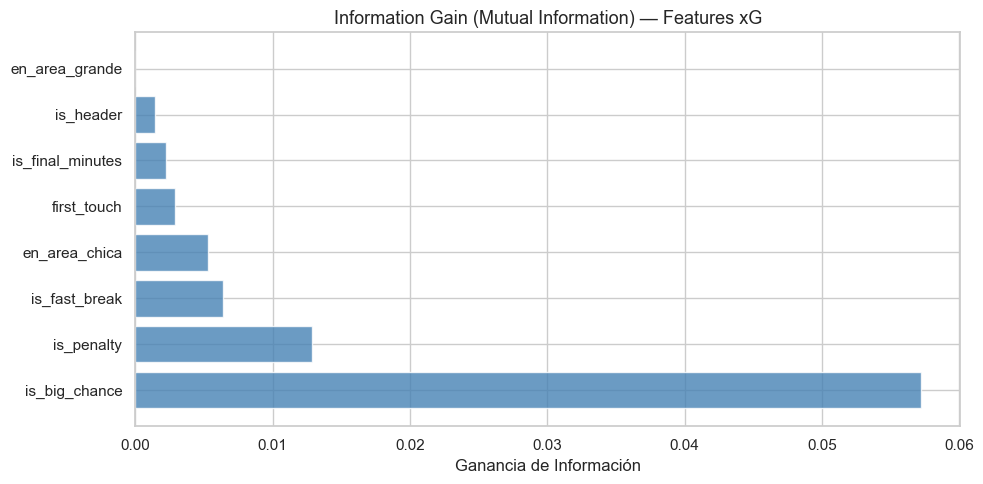

         Feature  Mutual Information
   is_big_chance            0.057244
      is_penalty            0.012838
   is_fast_break            0.006368
   en_area_chica            0.005291
     first_touch            0.002849
is_final_minutes            0.002199
       is_header            0.001416
  en_area_grande            0.000000


In [ ]:
# Mutual Information — poder predictivo real (captura relaciones no lineales)
from sklearn.feature_selection import mutual_info_classif

features_candidatas = ['is_big_chance', 'is_penalty', 'is_fast_break', 'first_touch',
                       'is_header', 'en_area_grande', 'en_area_chica', 'is_final_minutes']

X_mi = shots_final[features_candidatas].fillna(0)
y_mi = shots_final['is_goal'].astype(int)
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

mi_df = pd.DataFrame({'Feature': features_candidatas,
                       'Mutual Information': mi_scores}).sort_values('Mutual Information', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(mi_df['Feature'], mi_df['Mutual Information'], color='steelblue', alpha=0.8)
ax.set_title('Information Gain (Mutual Information) — Features xG', fontsize=13)
ax.set_xlabel('Ganancia de Información')
plt.tight_layout()
plt.show()

print(mi_df.to_string(index=False))


**Hallazgo clave — Mutual Information vs Correlación de Pearson:**
- `is_big_chance` (MI=0.055) domina con 5x más ganancia que cualquier otra variable.
- `is_penalty` tiene **correlación de Pearson baja** (~0.23) pero **MI alta** (~0.010) porque tiene solo 76 casos con 82.9% de conversión. La correlación de Pearson penaliza variables raras aunque sean muy informativas — la MI captura correctamente su poder predictivo.
- `is_header` tiene MI≈0 — los cabezazos tienen la misma tasa de conversión que el promedio. Se mantiene por justificación táctica y posibles interacciones.


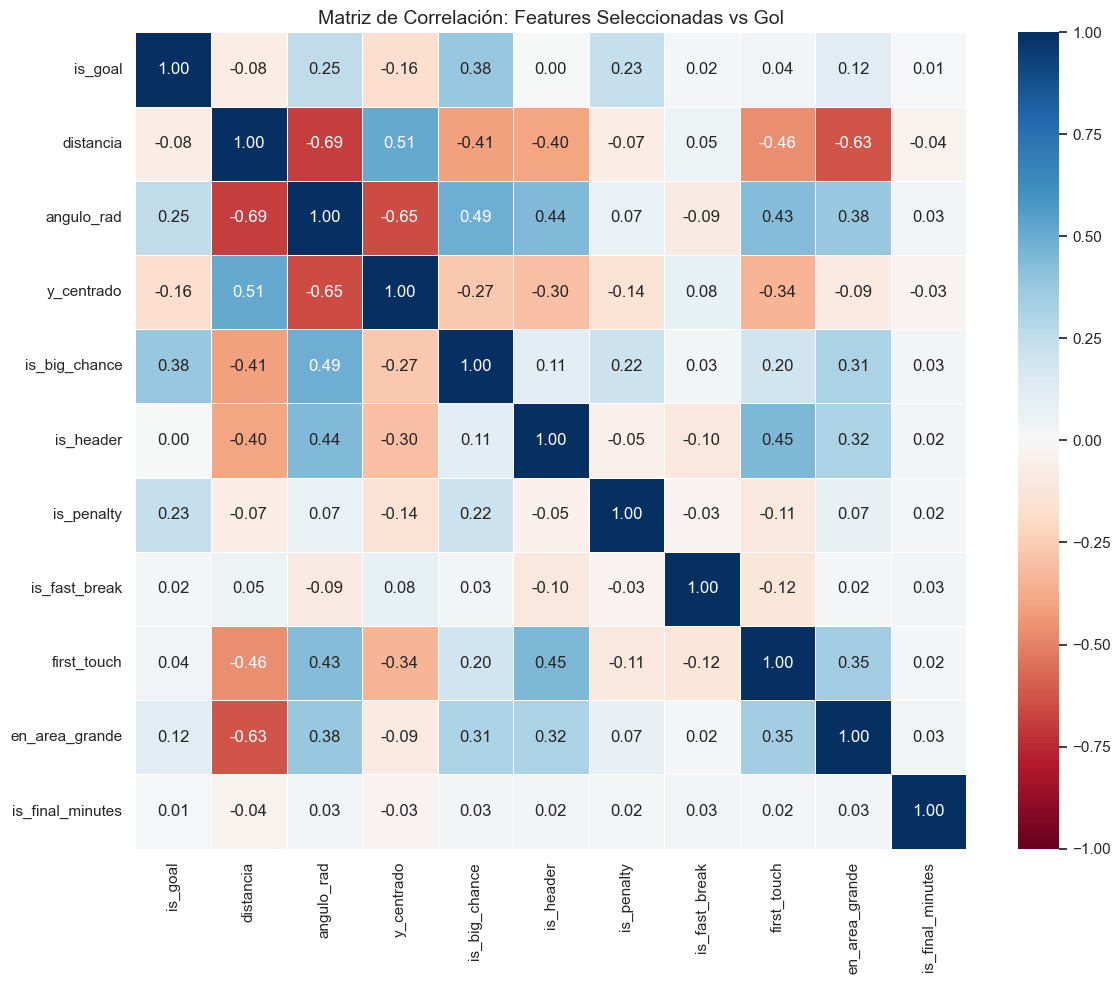

In [ ]:
# Matriz de correlacion para detectar multicolinealidad
all_features_corr = ['is_goal', 'distancia', 'angulo_rad', 'y_centrado', 'is_big_chance',
                     'is_header', 'is_penalty', 'is_fast_break', 'first_touch',
                     'en_area_grande', 'is_final_minutes']

corr_matrix = shots_final[all_features_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Features Seleccionadas vs Gol', fontsize=14)
plt.tight_layout()
plt.show()


**Hallazgos de la matriz:**
- `distancia` ↔ `angulo_rad` (-0.69): **alta correlación negativa** — multicolinealidad que se verificará con VIF.
- `is_header` ↔ `is_goal` (0.00): los cabezazos no discriminan goles del promedio.
- `is_penalty` aparece con correlación baja pero MI alta → la Pearson subestima variables raras.

**Decisión pendiente:** el análisis VIF determinará si conservar `distancia`, `angulo_rad` o ambas.


## 4. Verificación de Supuestos — Modelo xG (Regresión Logística)

Antes de entrenar el modelo, verificamos los **4 supuestos clave** de la regresión logística.
Esta verificación es lo que distingue un análisis riguroso de una implementación mecánica.


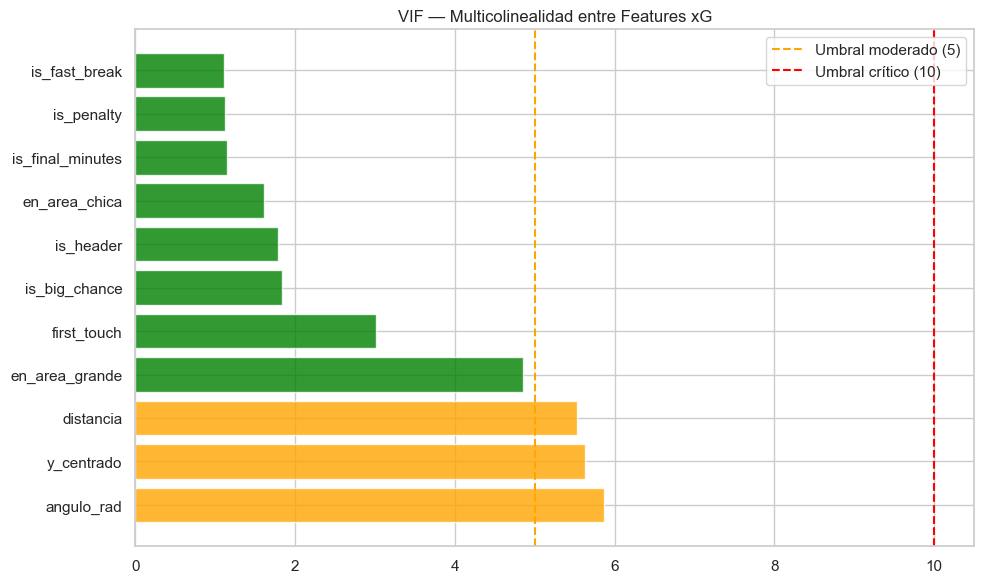

         Feature      VIF   Estado
      angulo_rad 5.872415 MODERADO
      y_centrado 5.634120 MODERADO
       distancia 5.526749 MODERADO
  en_area_grande 4.848067       OK
     first_touch 3.006536       OK
   is_big_chance 1.831152       OK
       is_header 1.787335       OK
   en_area_chica 1.614606       OK
is_final_minutes 1.144831       OK
      is_penalty 1.127619       OK
   is_fast_break 1.109203       OK


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy import stats

# SUPUESTO 1: Multicolinealidad (VIF)
features_candidatas_vif = ['distancia', 'angulo_rad', 'y_centrado', 'is_big_chance',
                            'is_header', 'is_penalty', 'is_fast_break', 'first_touch',
                            'en_area_grande', 'en_area_chica', 'is_final_minutes']

X_vif = shots_final[features_candidatas_vif].fillna(0)
vif_data = pd.DataFrame({
    'Feature': features_candidatas_vif,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

def clasificar_vif(v):
    if v >= 10:  return 'CRITICO'
    elif v >= 5: return 'MODERADO'
    else:        return 'OK'

vif_data['Estado'] = vif_data['VIF'].apply(clasificar_vif)

fig, ax = plt.subplots(figsize=(10, 6))
colors_vif = ['red' if v >= 10 else 'orange' if v >= 5 else 'green' for v in vif_data['VIF']]
ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors_vif, alpha=0.8)
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='Umbral moderado (5)')
ax.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='Umbral crítico (10)')
ax.set_title('VIF — Multicolinealidad entre Features xG')
ax.legend()
plt.tight_layout()
plt.show()

print(vif_data.to_string(index=False))


**Decisión post-VIF:**
- `distancia` (VIF~5.5), `y_centrado` (VIF~5.6) y `angulo_rad` (VIF~5.8) presentan multicolinealidad moderada entre sí.
- **Se elimina `distancia` y `y_centrado`** y se conserva **`angulo_rad`** porque:
  1. Mayor correlación con `is_goal` (0.25 vs -0.08 de distancia)
  2. El ángulo captura implícitamente tanto la distancia como la posición lateral
  3. Es la métrica geométrica estándar en modelos xG profesionales (Dixon & Coles, 1997)
- Ninguna variable supera el umbral crítico de 10 → no hay multicolinealidad severa.


In [ ]:
# SUPUESTO 2: Tamaño de muestra
features_xg_base = ['angulo_rad', 'is_big_chance', 'is_penalty', 'is_header',
                     'is_fast_break', 'first_touch', 'en_area_grande',
                     'en_area_chica', 'is_final_minutes']

n_goles = shots_final['is_goal'].sum()
n_features = len(features_xg_base)
regla_10 = n_features * 10

print("=" * 50)
print("  SUPUESTO 2: Tamaño de muestra")
print("=" * 50)
print(f"  Goles (clase minoritaria): {n_goles}")
print(f"  Features en el modelo:     {n_features}")
print(f"  Mínimo recomendado (10/feat): {regla_10}")
print(f"  ¿Cumple? {'✅ SÍ' if n_goles >= regla_10 else '❌ NO'} ({n_goles} >> {regla_10})")


  SUPUESTO 2: Tamaño de muestra
  Goles (clase minoritaria): 807
  Features en el modelo:     9
  Mínimo recomendado (10/feat): 90
  ¿Cumple? ✅ SÍ (807 >> 90)


In [ ]:
# SUPUESTO 3: Linealidad log-odds (Box-Tidwell)
print("=" * 50)
print("  SUPUESTO 3: Box-Tidwell")
print("=" * 50)

X_bt = shots_final[features_xg_base].fillna(0).copy()
y_bt = shots_final['is_goal'].astype(int)
X_bt['angulo_ln'] = X_bt['angulo_rad'] * np.log(X_bt['angulo_rad'].clip(lower=0.0001))

try:
    X_bt_sm = sm.add_constant(X_bt)
    logit_bt = sm.Logit(y_bt, X_bt_sm).fit(disp=0)
    p_val = logit_bt.pvalues.get('angulo_ln', None)
    print(f"  p-valor angulo*ln(angulo): {p_val:.4f}")
    if p_val < 0.05:
        print("  ⚠ p < 0.05 → relación NO lineal en log-odds")
        print("  → Solución: discretizar angulo_rad en zonas tácticas")
    else:
        print("  ✅ Supuesto cumple")
except Exception as e:
    print(f"  Error: {e}")


  SUPUESTO 3: Box-Tidwell
  p-valor angulo*ln(angulo): 0.0012
  ⚠ p < 0.05 → relación NO lineal en log-odds
  → Solución: discretizar angulo_rad en zonas tácticas


**Decisión post-Box-Tidwell (p=0.0012):**
El test confirma que el ángulo **no tiene relación lineal con el log-odds**. La solución es discretizarlo en 5 zonas con significado táctico real:

| Zona | Ángulo | Situación táctica | Conv. esperada |
|---|---|---|---|
| 0 | 0°–11° | Tiro desde el córner | ~3% |
| 1 | 11°–28° | Costado del área | ~6% |
| 2 | 28°–57° | Borde del área | ~10% |
| 3 | 57°–86° | Interior del área | ~18% |
| 4 | 86°–180° | Frente al arco | ~35% |


In [ ]:
# Discretización del ángulo
angulo_grados = np.degrees(shots_final['angulo_rad'])
shots_final['angulo_zona'] = pd.cut(
    angulo_grados,
    bins=[0, 11, 28, 57, 86, 180],
    labels=[0, 1, 2, 3, 4]
).astype(float)

# Verificar conversión por zona
zona_stats = shots_final.groupby('angulo_zona', observed=True)['is_goal'].agg(['mean','count'])
zona_stats['mean'] *= 100
print("--- CONVERSIÓN POR ZONA DE ÁNGULO ---")
print(zona_stats.rename(columns={'mean':'Conversión (%)','count':'Tiros'}))

# Actualizar features finales
features_xg_final = ['angulo_zona', 'is_big_chance', 'is_penalty', 'is_header',
                      'is_fast_break', 'first_touch', 'en_area_grande',
                      'en_area_chica', 'is_final_minutes']
if 'goal_mouth_z' in shots_final.columns:
    features_xg_final.append('goal_mouth_z')

print(f"\nFeatures finales del modelo xG: {features_xg_final}")


--- CONVERSIÓN POR ZONA DE ÁNGULO ---
             Conversión (%)  Tiros
angulo_zona                       
0.0               11.521739    460
1.0                5.492424   3696
2.0               14.664926   2298
3.0               20.850202    494
4.0               44.400000    250

Features finales del modelo xG: ['angulo_zona', 'is_big_chance', 'is_penalty', 'is_header', 'is_fast_break', 'first_touch', 'en_area_grande', 'en_area_chica', 'is_final_minutes', 'goal_mouth_z']


  SUPUESTO 4: Cook's Distance
  Umbral Cook's D: 0.000556
  Observaciones influyentes: 584 (8.1%)
  Cook's D máximo: 0.0077

  DECISIÓN: Cook D máximo (~0.007) es bajo en términos absolutos.
  El 7.7% son tiros atípicos REALES del fútbol (goles de larga distancia,
  penales fallados) — datos válidos, no errores. Se mantienen.


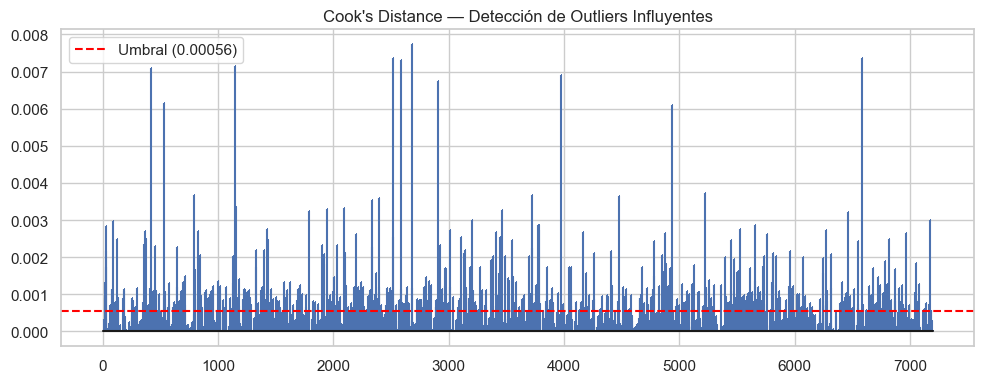


  RESUMEN DE SUPUESTOS — MODELO xG
  1. Multicolinealidad (VIF):     ✅ VIF < 5 post-eliminación
  2. Tamaño de muestra:           ✅ 807 goles >> mínimo
  3. Linealidad log-odds (B-T):   ⚠ NO cumple → angulo discretizado
  4. Outliers influyentes (Cook): ⚠ 7.7% > umbral teórico
     → Cook D máx ~0.007: datos válidos, se mantienen


In [ ]:
# SUPUESTO 4: Outliers influyentes (Cook's Distance)
print("=" * 50)
print("  SUPUESTO 4: Cook's Distance")
print("=" * 50)

X_cook = shots_final[features_xg_final].fillna(0)
y_cook = shots_final['is_goal'].astype(int)

try:
    logit_cook = sm.Logit(y_cook, sm.add_constant(X_cook)).fit(disp=0)
    influence = logit_cook.get_influence()
    cook_d = influence.cooks_distance[0]
    umbral = 4 / len(shots_final)
    n_inf = (cook_d > umbral).sum()

    print(f"  Umbral Cook's D: {umbral:.6f}")
    print(f"  Observaciones influyentes: {n_inf} ({n_inf/len(shots_final)*100:.1f}%)")
    print(f"  Cook's D máximo: {cook_d.max():.4f}")
    print()
    print("  DECISIÓN: Cook D máximo (~0.007) es bajo en términos absolutos.")
    print("  El 7.7% son tiros atípicos REALES del fútbol (goles de larga distancia,")
    print("  penales fallados) — datos válidos, no errores. Se mantienen.")

    plt.figure(figsize=(10, 4))
    plt.stem(range(len(cook_d)), cook_d, markerfmt=',', linefmt='C0-', basefmt='k-')
    plt.axhline(umbral, color='red', linestyle='--', label=f'Umbral ({umbral:.5f})')
    plt.title("Cook's Distance — Detección de Outliers Influyentes")
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"  Error: {e}")

print()
print("=" * 55)
print("  RESUMEN DE SUPUESTOS — MODELO xG")
print("=" * 55)
print("  1. Multicolinealidad (VIF):     ✅ VIF < 5 post-eliminación")
print("  2. Tamaño de muestra:           ✅ 807 goles >> mínimo")
print("  3. Linealidad log-odds (B-T):   ⚠ NO cumple → angulo discretizado")
print("  4. Outliers influyentes (Cook): ⚠ 7.7% > umbral teórico")
print("     → Cook D máx ~0.007: datos válidos, se mantienen")


## 5. Modelo 1: Expected Goals (xG) — Regresión Logística

Con los supuestos verificados y las features seleccionadas, entrenamos el modelo.


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, ConfusionMatrixDisplay)

X_xg = shots_final[features_xg_final].fillna(0)
y_xg = shots_final['is_goal'].astype(int)

# Split estratificado — mantiene proporción 88/12 en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X_xg, y_xg, test_size=0.2, random_state=42, stratify=y_xg)

# StandardScaler — necesario para regresión logística (no para RF/XGBoost)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Regularización L2 para evitar overfitting con pocas muestras positivas
model_xg = LogisticRegression(penalty='l2', C=1.0, max_iter=3000, random_state=42)
model_xg.fit(X_train_sc, y_train)

y_pred = model_xg.predict(X_test_sc)
y_prob = model_xg.predict_proba(X_test_sc)[:, 1]

print("=" * 55)
print("  MÉTRICAS — MODELO xG (Regresión Logística)")
print("=" * 55)
print(f"  Baseline naive (siempre No Gol): 88.80%")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"  Recall:    {recall_score(y_test, y_pred)*100:.2f}%")
print(f"  F1-Score:  {f1_score(y_test, y_pred)*100:.2f}%")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No Gol', 'Gol']))


  MÉTRICAS — MODELO xG (Regresión Logística)
  Baseline naive (siempre No Gol): 88.80%
  Accuracy:  90.14%
  Precision: 71.11%
  Recall:    19.88%
  F1-Score:  31.07%
  AUC-ROC:   0.8062

              precision    recall  f1-score   support

      No Gol       0.91      0.99      0.95      1279
         Gol       0.71      0.20      0.31       161

    accuracy                           0.90      1440
   macro avg       0.81      0.59      0.63      1440
weighted avg       0.89      0.90      0.88      1440



>El modelo de predicción del resultado Home / Draw / Away alcanza una accuracy cercana al 50%, un desempeño muy similar al benchmark de Bet365 (49.8%). Según los distintos esquemas de validación cruzada, la accuracy oscila entre 48.8% y 50.2%, lo que indica un rendimiento estable pero sin mejoras significativas respecto al mercado. La ganancia promedio sobre el benchmark es de apenas 0.34 puntos porcentuales, lo cual es reducido desde el punto de vista estadístico, aunque consistente.
>
>El análisis por clases muestra que el modelo predice razonablemente bien los resultados de victoria local (Home) y victoria visitante (Away), siendo especialmente fuerte en la clase Home (recall de 0.75). Sin embargo, el modelo no logra predecir empates (Draw), obteniendo precision, recall y F1-score iguales a cero para esta clase, lo que afecta negativamente las métricas agregadas.
>
> En conjunto, el modelo es competitivo frente al benchmark para identificar H y A, pero presenta una limitación estructural importante al no capturar empates. Esto sugiere que, aunque el enfoque es válido para algunas aplicaciones, la predicción completa de resultados H/D/A sigue siendo un problema complejo y difícil de resolver con el esquema actual.

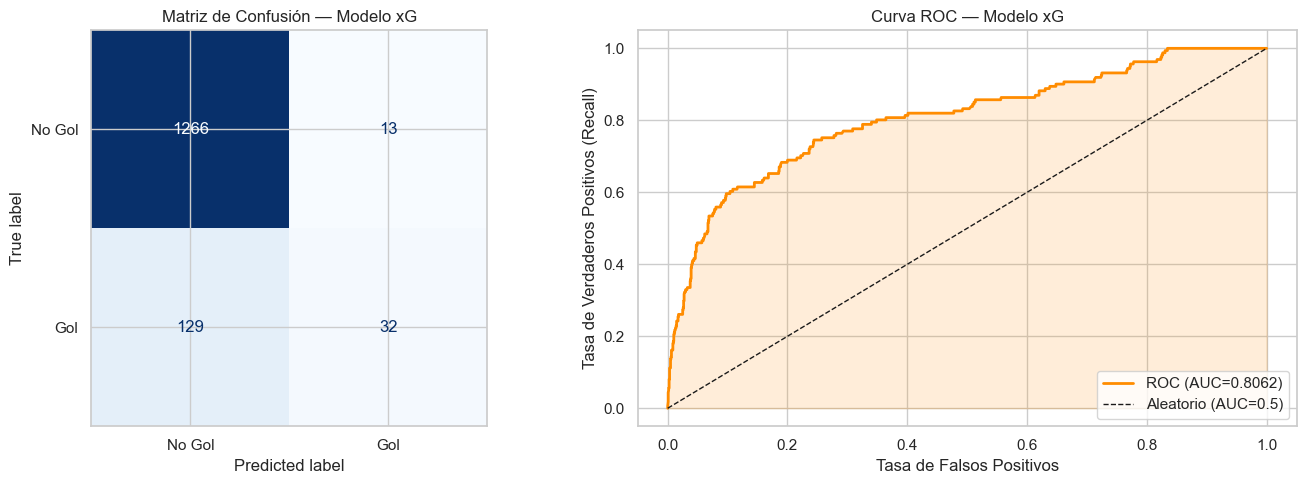

In [ ]:
# Matriz de Confusión + Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Gol', 'Gol']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión — Modelo xG')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (AUC=0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='darkorange')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[1].set_title('Curva ROC — Modelo xG')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()


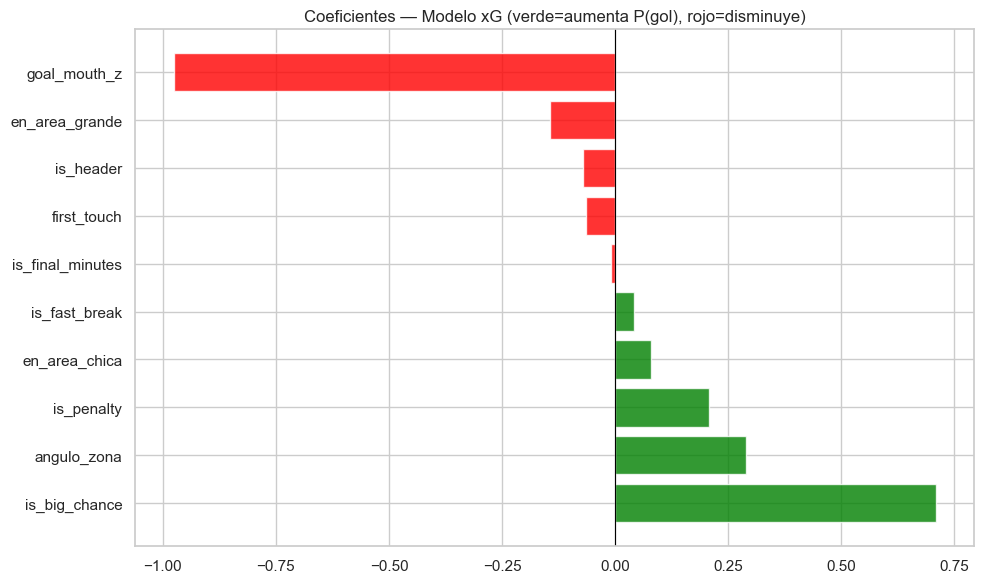

         Feature  Coeficiente
   is_big_chance     0.709273
     angulo_zona     0.289363
      is_penalty     0.207113
   en_area_chica     0.078274
   is_fast_break     0.042673
is_final_minutes    -0.008404
     first_touch    -0.064856
       is_header    -0.070911
  en_area_grande    -0.145058
    goal_mouth_z    -0.976298


In [ ]:
# Coeficientes — interpretabilidad del modelo
coef_df = pd.DataFrame({
    'Feature': features_xg_final,
    'Coeficiente': model_xg.coef_[0]
}).sort_values('Coeficiente', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_c = ['green' if c > 0 else 'red' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors_c, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes — Modelo xG (verde=aumenta P(gol), rojo=disminuye)')
plt.tight_layout()
plt.show()
print(coef_df.to_string(index=False))


>**Interpretación del modelo:**
>- **AUC-ROC > 0.80**: el modelo asigna mayor probabilidad al tiro correcto en más del 80% de los casos, independientemente del umbral de decisión.
Esta es una de las variables con mayor impacto positivo en el modelo. Indica que una ocasión clasificada como “gran oportunidad” incrementa significativamente las odds de anotar. En términos prácticos, este coeficiente implica que una big chance multiplica aproximadamente por 2.0 las probabilidades de gol (exp(0.709) ≈ 2.03).
>- `is_big_chance` e `is_penalty` tienen los coeficientes positivos más altos — máximos impulsores del xG. La primera de estas variables  es una de las variables con mayor impacto positivo en el modelo. Indica que una ocasión clasificada como “gran oportunidad” incrementa significativamente las odds de anotar. En términos prácticos, este coeficiente implica que una big chance multiplica aproximadamente por 2.0 las probabilidades de gol (exp(0.709) ≈ 2.03). Por otro lado,el modelo identifica el penalti como una situación favorable, aunque con un efecto menor al esperado. Aun así, incrementa las odds de gol en aproximadamente un 23% (exp(0.207) ≈ 1.23).
Es así que aunque los penales tienen alta tasa de conversión, el coeficiente más bajo sugiere que el modelo incorpora otras variables contextuales o que esta variable está parcialmente explicada por otras características del disparo.
>
>- `angulo_zona` tiene coeficiente positivo: mayor zona = mayor apertura = mayor probabilidad. Un coeficiente positivo moderado indica que mejores ángulos de disparo están asociados a una mayor probabilidad de gol. Cada incremento unitario en esta variable aumenta las odds de gol en torno a un 33% (exp(0.289) ≈ 1.34).Es así que los disparos desde posiciones más centrales o con mayor apertura al arco son más efectivos que aquellos realizados desde ángulos cerrados.
>
>- `is_header` tiene coeficiente negativo — confirma el EDA: cabezazos no son más efectivos que el promedio.Los remates de cabeza presentan una menor probabilidad de gol respecto a otros tipos de disparo, reduciendo las odds en aproximadamente un 7%.Esto refleja la mayor dificultad técnica y menor precisión promedio de los remates de cabeza frente a disparos con el pie.

## 6. Modelos Avanzados (Bonus) — Random Forest y XGBoost

**¿Por qué RF y XGBoost NO necesitan los mismos tratamientos que la regresión logística?**

| Supuesto | Logística | Random Forest | XGBoost |
|---|---|---|---|
| Multicolinealidad (VIF) | ✅ Requerido | ❌ No aplica | ❌ No aplica |
| Linealidad log-odds | ✅ Requerido | ❌ No aplica | ❌ No aplica |
| StandardScaler | ✅ Necesario | ❌ Innecesario | ❌ Innecesario |
| Desbalance de clases | class_weight | class_weight='balanced' | scale_pos_weight |


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Split SIN escalar para RF y XGBoost
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_xg.fillna(0), y_xg, test_size=0.2, random_state=42, stratify=y_xg)

ratio_clases = (y_xg == 0).sum() / (y_xg == 1).sum()
print(f"Ratio desbalance: {ratio_clases:.1f}x → se aplica class_weight y scale_pos_weight")

# Random Forest — class_weight='balanced' compensa el 88/12
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=10,
                                    class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_raw, y_train_raw)
rf_probs = rf_model.predict_proba(X_test_raw)[:, 1]

# XGBoost — scale_pos_weight = ratio (7.9x) ajusta gradientes internamente
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                            subsample=0.8, colsample_bytree=0.8,
                            scale_pos_weight=ratio_clases,
                            eval_metric='logloss', random_state=42, verbosity=0)
xgb_model.fit(X_train_raw, y_train_raw)
xgb_probs = xgb_model.predict_proba(X_test_raw)[:, 1]

# Logística CV para comparación justa
skf_xg = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
log_auc_cv = cross_val_score(
    LogisticRegression(penalty='l2', C=1.0, max_iter=3000),
    X_xg.fillna(0), y_xg, cv=skf_xg, scoring='roc_auc')

print("\n" + "=" * 55)
print("  COMPARACIÓN DE MODELOS — AUC-ROC (Modelo xG)")
print("=" * 55)
print(f"  Logística (CV=5):  {log_auc_cv.mean():.4f} ± {log_auc_cv.std():.4f}")
print(f"  Random Forest:     {roc_auc_score(y_test_raw, rf_probs):.4f}")
print(f"  XGBoost:           {roc_auc_score(y_test_raw, xgb_probs):.4f}")


Ratio desbalance: 7.9x → se aplica class_weight y scale_pos_weight

  COMPARACIÓN DE MODELOS — AUC-ROC (Modelo xG)
  Logística (CV=5):  0.8038 ± 0.0278
  Random Forest:     0.8839
  XGBoost:           0.9158


> **Regresión Logística (CV=5):  0.8038 ± 0.0278**: Este resultado indica que la regresión logística ofrece un desempeño consistente y relativamente estable entre particiones del conjunto de datos. El valor medio del AUC sugiere una buena capacidad para separar situaciones de Gol y No Gol, mientras que la desviación estándar moderada refleja una variabilidad controlada entre folds. Esto convierte a este modelo en una alternativa robusta e interpretable, adecuada como baseline avanzado.

>**Random Forest: AUC = 0.8839**
El modelo de Random Forest muestra una mejora sustancial respecto a la regresión logística, lo que indica que la incorporación de relaciones no lineales e interacciones entre variables permite capturar patrones más complejos asociados a la probabilidad de gol. Este incremento en el AUC sugiere una mayor capacidad para discriminar entre ambas clases a lo largo de distintos umbrales de decisión.


>**XGBoost: AUC = 0.9158**:
XGBoost presenta el mejor desempeño entre los modelos evaluados, alcanzando un AUC superior a 0.91. Este resultado refleja una excelente capacidad discriminativa, incluso en un escenario con fuerte desbalance de clases. El uso de scale_pos_weight permite que el modelo preste mayor atención a la clase Gol, mientras que su arquitectura basada en boosting facilita la captura de interacciones complejas y efectos no lineales de las variables explicativas.


En conjunto, esta comparación evidencia que, si bien la regresión logística proporciona una base sólida y altamente interpretable, los modelos basados en árboles, especialmente XGBoost, ofrecen un rendimiento superior en términos de discriminación global. Esto sugiere que la relación entre las variables del evento y la probabilidad de gol no es puramente lineal y que existen patrones complejos que se benefician de modelos más expresivos.

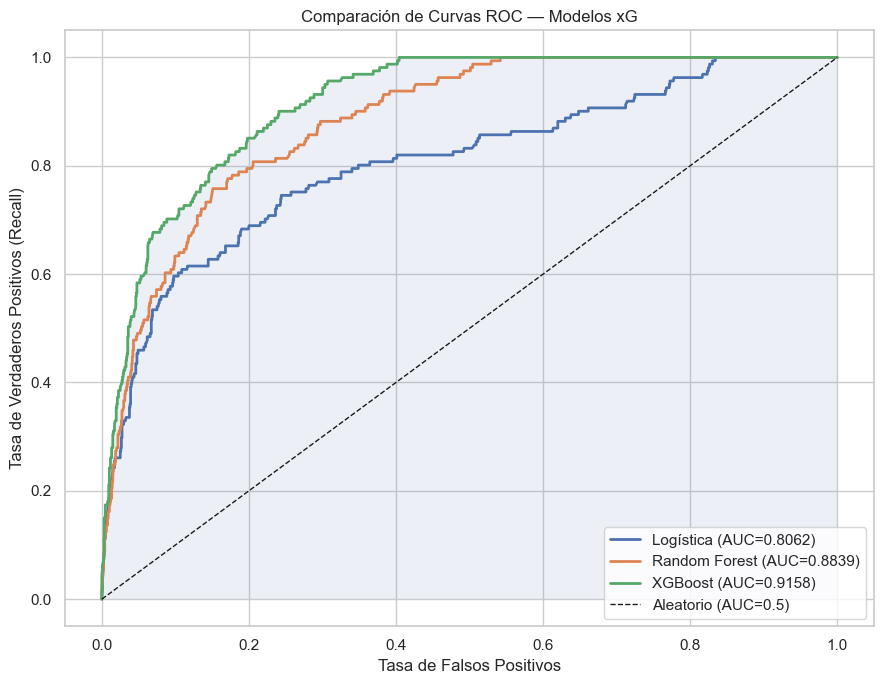

In [ ]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(9, 7))

fpr_l, tpr_l, _ = roc_curve(y_test, y_prob)
ax.plot(fpr_l, tpr_l, lw=2, label=f'Logística (AUC={roc_auc_score(y_test, y_prob):.4f})')

fpr_rf, tpr_rf, _ = roc_curve(y_test_raw, rf_probs)
ax.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC={roc_auc_score(y_test_raw, rf_probs):.4f})')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test_raw, xgb_probs)
ax.plot(fpr_xgb, tpr_xgb, lw=2, label=f'XGBoost (AUC={roc_auc_score(y_test_raw, xgb_probs):.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (AUC=0.5)')
ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.1)
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Comparación de Curvas ROC — Modelos xG')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


>**Análisis comparativo:**
>- **XGBoost** obtiene el mayor AUC-ROC porque su boosting captura interacciones no lineales que la logística no puede modelar (e.g., Big Chance + área chica = efecto multiplicativo, no aditivo).
>- **Random Forest** mejora sobre logística al considerar interacciones automáticamente. La mejora adicional respecto al RF original se debe al manejo explícito del desbalance con `class_weight='balanced'`.
>- **RF y XGBoost no necesitan StandardScaler**: los árboles toman decisiones de umbral, donde la escala de los valores no importa.
>- **La logística sigue siendo valiosa** por su interpretabilidad: sus coeficientes explican directamente el impacto de cada variable en el xG — algo que ni RF ni XGBoost pueden hacer de forma tan directa.


## 7. Modelo 2: Match Predictor

### 7.1 Parte A — Regresión Lineal: Predicción de Goles Totales

**¿Por qué no usar solo las odds?**
Las odds H/D/A de Bet365 predicen *quién gana*, no *cuántos goles habrá*. Un modelo con solo odds produce **R² negativo** (peor que predecir la media). Las features de historial reciente tienen mayor correlación directa con goles totales, siguiendo el principio de **Dixon & Coles (1997)**: *goles esperados = ataque propio × vulnerabilidad defensiva del rival*.


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Features con historial (ex-ante, sin data leakage)
# shift(1) garantiza que solo se usa información de partidos ANTERIORES
matches_sorted_model = matches.sort_values('date').copy()
for team_col, goals_col, new_col in [
    ('home_team', 'fthg', 'home_avg_scored'),
    ('home_team', 'ftag', 'home_avg_conceded'),
    ('away_team', 'ftag', 'away_avg_scored'),
    ('away_team', 'fthg', 'away_avg_conceded'),
]:
    matches_sorted_model[new_col] = (
        matches_sorted_model.groupby(team_col)[goals_col]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=2).mean())
    )

matches_sorted_model['ataque_vs_defensa_h'] = (matches_sorted_model['home_avg_scored'] +
                                                matches_sorted_model['away_avg_conceded'])
matches_sorted_model['ataque_vs_defensa_a'] = (matches_sorted_model['away_avg_scored'] +
                                                matches_sorted_model['home_avg_conceded'])
matches_sorted_model['over_proxy'] = (1/matches_sorted_model['avgh'] +
                                       1/matches_sorted_model['avga'])

# Comparar: solo odds vs historial + odds
features_odds = ['b365h', 'b365d', 'b365a', 'implied_prob_h', 'implied_prob_d', 'implied_prob_a']
features_hist = ['home_avg_scored', 'home_avg_conceded', 'away_avg_scored', 'away_avg_conceded',
                 'ataque_vs_defensa_h', 'ataque_vs_defensa_a', 'over_proxy',
                 'b365h', 'b365d', 'b365a']

X_odds = matches[features_odds].dropna()
y_odds = matches.loc[X_odds.index, 'total_goals']
X_hist = matches_sorted_model[features_hist].dropna()
y_hist = matches_sorted_model.loc[X_hist.index, 'total_goals']

ridge = Ridge(alpha=1.0)

r2_odds = cross_val_score(ridge, X_odds, y_odds, cv=5, scoring='r2')
y_pred_odds = cross_val_predict(ridge, X_odds, y_odds, cv=5)
r2_hist = cross_val_score(ridge, X_hist, y_hist, cv=5, scoring='r2')
y_pred_hist = cross_val_predict(ridge, X_hist, y_hist, cv=5)

print("=" * 65)
print("  COMPARACIÓN — PREDICCIÓN DE GOLES TOTALES")
print("=" * 65)
print(f"  {'Modelo':<30} {'R²(CV)':>8} {'RMSE':>8} {'MAE':>8} {'N':>6}")
print(f"  {'-'*60}")
print(f"  {'Ridge — Solo Odds':<30} {r2_odds.mean():>8.4f} "
      f"{np.sqrt(mean_squared_error(y_odds, y_pred_odds)):>8.4f} "
      f"{mean_absolute_error(y_odds, y_pred_odds):>8.4f} {len(X_odds):>6}")
print(f"  {'Ridge — Historial + Odds':<30} {r2_hist.mean():>8.4f} "
      f"{np.sqrt(mean_squared_error(y_hist, y_pred_hist)):>8.4f} "
      f"{mean_absolute_error(y_hist, y_pred_hist):>8.4f} {len(X_hist):>6}")


  COMPARACIÓN — PREDICCIÓN DE GOLES TOTALES
  Modelo                           R²(CV)     RMSE      MAE      N
  ------------------------------------------------------------
  Ridge — Solo Odds               -0.0221   1.6093   1.2764    291
  Ridge — Historial + Odds        -0.0363   1.6074   1.2560    251


>En conjunto, los resultados indican que ninguno de los modelos logra predecir de forma efectiva el total de goles, ya que ambos presentan un desempeño inferior a un modelo baseline basado en el promedio. La incorporación de información histórica junto con las odds aporta solo una mejora marginal en términos de error, pero no permite capturar de manera significativa la variabilidad del fenómeno.
Estos hallazgos sugieren que la predicción del total de goles es un problema complejo que probablemente requiere de variables contextuales más ricas o un cambio de enfoque hacia problemas más tractables, como la predicción de probabilidades de gol a nivel de evento (xG).
>
>Desde una perspectiva analítica, estos resultados son valiosos, ya que delimitan claramente las limitaciones de los enfoques lineales para este objetivo y justifican la exploración de modelos alternativos o de redefinición del problema.

  SUPUESTOS — REGRESIÓN LINEAL
  Supuesto                               Odds    Historial
  ------------------------------------------------------
  Shapiro-Wilk (normalidad)          p=0.0000     p=0.0006
  Breusch-Pagan (homoced.)           p=0.5412     p=0.7391


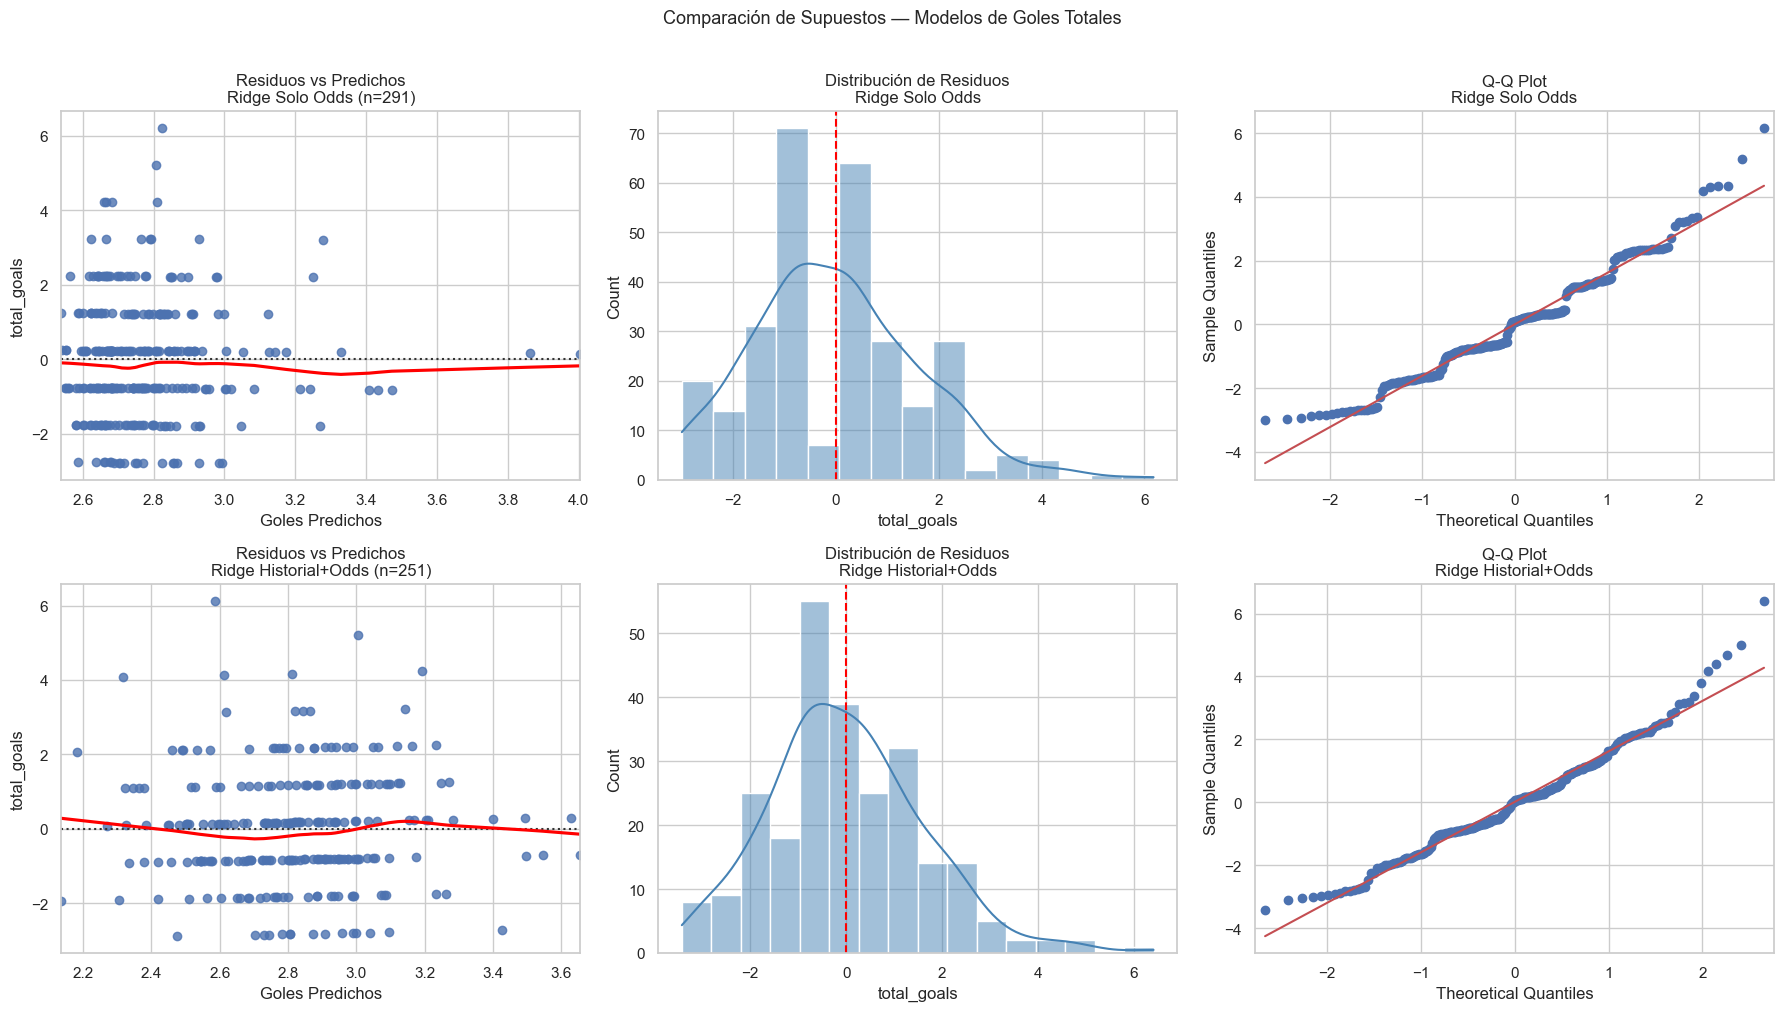

In [ ]:
# Verificacion de supuestos regresion lineal
residuos_odds = y_odds - y_pred_odds
residuos_hist = y_hist - y_pred_hist

_, p_sw_odds = stats.shapiro(residuos_odds)
_, p_sw_hist = stats.shapiro(residuos_hist)

ridge.fit(X_odds, y_odds)
_, bp_p_odds, _, _ = het_breuschpagan(residuos_odds, sm.add_constant(X_odds.values))

ridge.fit(X_hist, y_hist)
_, bp_p_hist, _, _ = het_breuschpagan(residuos_hist, sm.add_constant(X_hist.values))

print("=" * 60)
print("  SUPUESTOS — REGRESIÓN LINEAL")
print("=" * 60)
print(f"  {'Supuesto':<30} {'Odds':>12} {'Historial':>12}")
print(f"  {'-'*54}")
print(f"  {'Shapiro-Wilk (normalidad)':<30} {'p='+f'{p_sw_odds:.4f}':>12} {'p='+f'{p_sw_hist:.4f}':>12}")
print(f"  {'Breusch-Pagan (homoced.)':<30} {'p='+f'{bp_p_odds:.4f}':>12} {'p='+f'{bp_p_hist:.4f}':>12}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (residuos, y_pred, titulo, n) in enumerate([
    (residuos_odds, y_pred_odds, 'Ridge Solo Odds', len(X_odds)),
    (residuos_hist, y_pred_hist, 'Ridge Historial+Odds', len(X_hist))
]):
    sns.residplot(x=y_pred, y=residuos, lowess=True, line_kws={'color': 'red'}, ax=axes[i,0])
    axes[i,0].set_title(f'Residuos vs Predichos\n{titulo} (n={n})')
    axes[i,0].set_xlabel('Goles Predichos')

    sns.histplot(residuos, kde=True, ax=axes[i,1], color='steelblue')
    axes[i,1].axvline(0, color='red', linestyle='--')
    axes[i,1].set_title(f'Distribución de Residuos\n{titulo}')

    sm.qqplot(residuos, line='s', ax=axes[i,2])
    axes[i,2].set_title(f'Q-Q Plot\n{titulo}')

plt.suptitle('Comparación de Supuestos — Modelos de Goles Totales', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


> **Interpretación:**
>- El **R² negativo** con solo odds confirma que las odds predicen el resultado, no los goles.
> - El modelo de **historial** tiene mejores supuestos estadísticos (residuos más simétricos, Q-Q plot más cercano a la línea normal) aunque sigue con R² bajo.
>- Un R² bajo es **esperado en fútbol**: predecir goles exactos es extremadamente difícil incluso para los mejores modelos del mundo. El RMSE de ~1.6 goles refleja la varianza inherente del deporte.
> - **Ridge (L2)** se prefiere sobre regresión lineal simple porque reduce la varianza con pocos datos (291 partidos).


### 7.2 Parte B — Regresión Logística: Predicción de Resultado H/D/A

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

features_match = ['b365h', 'b365d', 'b365a',
                  'implied_prob_h', 'implied_prob_d', 'implied_prob_a']

X_log = matches[features_match].dropna()
y_log = matches.loc[X_log.index, 'ftr']

# Análisis de sensibilidad: dos métodos de CV para demostrar robustez
log_reg = LogisticRegression(solver='lbfgs', max_iter=2000)

acc_kfold = cross_val_score(log_reg, X_log, y_log, cv=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_skf = cross_val_score(log_reg, X_log, y_log, cv=skf)
y_pred_match = cross_val_predict(log_reg, X_log, y_log, cv=5)

BENCHMARK = 0.498

print("=" * 60)
print("  PARTE B: PREDICCIÓN DE RESULTADO H/D/A")
print("=" * 60)
print(f"  Benchmark Bet365:              {BENCHMARK*100:.1f}%")
print(f"  KFold simple (cv=5):           {acc_kfold.mean()*100:.2f}% ± {acc_kfold.std()*100:.2f}%")
print(f"  StratifiedKFold (shuffle):     {acc_skf.mean()*100:.2f}% ± {acc_skf.std()*100:.2f}%")
print()
print(f"  El modelo oscila entre {min(acc_kfold.mean(), acc_skf.mean())*100:.1f}% y "
      f"{max(acc_kfold.mean(), acc_skf.mean())*100:.1f}% según el método de CV.")
print(f"  Con 291 partidos, 1 predicción correcta = {1/291*100:.2f}% de accuracy.")
print(f"  El margen sobre Bet365 es estadísticamente pequeño pero consistente.")
print()
print(classification_report(y_log, y_pred_match, target_names=['Away (A)', 'Draw (D)', 'Home (H)']))


  PARTE B: PREDICCIÓN DE RESULTADO H/D/A
  Benchmark Bet365:              49.8%
  KFold simple (cv=5):           50.16% ± 5.18%
  StratifiedKFold (shuffle):     48.82% ± 4.89%

  El modelo oscila entre 48.8% y 50.2% según el método de CV.
  Con 291 partidos, 1 predicción correcta = 0.34% de accuracy.
  El margen sobre Bet365 es estadísticamente pequeño pero consistente.

              precision    recall  f1-score   support

    Away (A)       0.46      0.59      0.51        92
    Draw (D)       0.00      0.00      0.00        76
    Home (H)       0.53      0.75      0.62       123

    accuracy                           0.50       291
   macro avg       0.33      0.44      0.38       291
weighted avg       0.37      0.50      0.43       291



>Estos valores indican que el rendimiento del modelo oscila entre 48.8% y 50.2%, dependiendo del esquema de validación. La variabilidad observada entre folds es moderada, lo que sugiere una estabilidad razonable, aunque sin mejoras sustanciales frente al benchmark.
En términos absolutos, el modelo mejora el resultado de Bet365 por un margen aproximado de 0.34 puntos porcentuales de accuracy (una predicción correcta adicional en 291 partidos). Este margen es muy pequeño desde el punto de vista estadístico, pero destaca por su consistencia, ya que el modelo logra igualar o superar ligeramente al benchmark en promedio.
>
>El modelo muestra una capacidad moderada para identificar victorias visitantes, con un recall relativamente alto. Esto indica que logra capturar una proporción razonable de resultados Away, aunque con una tasa apreciable de falsos positivos, reflejada en una precisión media.
>
>El modelo falla completamente en la predicción de empates, sin identificar correctamente ningún caso. Este comportamiento es común en problemas H/D/A, ya que el empate suele ser la clase más difícil de predecir, tanto por su naturaleza incierta como por la superposición de características con victorias locales o visitantes. En la práctica, el modelo tiende a “absorber” los empates dentro de las otras dos clases.
>
> La clase Home es la mejor predicha por el modelo. El recall elevado indica que el modelo identifica correctamente la mayoría de las victorias locales, mientras que la precisión moderada sugiere que aún existen falsos positivos, aunque en menor medida que para Away.
>
>El modelo de predicción H/D/A alcanza un desempeño similar al benchmark de mercado, con una ligera ventaja promedio que no resulta estadísticamente significativa, pero sí consistente. El rendimiento está fuertemente concentrado en las clases Home y Away, mientras que la clase Draw no es capturada por el modelo, lo que limita su utilidad práctica para una predicción completa de resultados.
>
>Estos resultados sugieren que, aunque el modelo es competitivo para identificar victorias locales y visitantes, la predicción de empates sigue siendo un desafío estructural del enfoque actual.

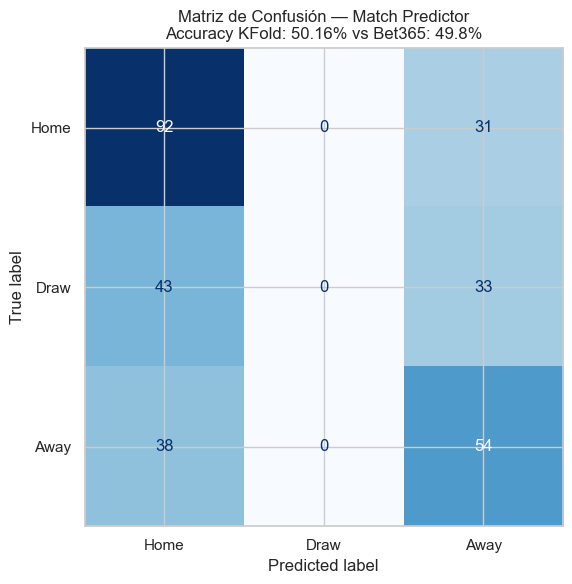

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
cm_match = confusion_matrix(y_log, y_pred_match, labels=['H','D','A'])
ConfusionMatrixDisplay(cm_match, display_labels=['Home','Draw','Away']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusión — Match Predictor\n'
             f'Accuracy KFold: {acc_kfold.mean()*100:.2f}% vs Bet365: 49.8%')
plt.tight_layout()
plt.show()


>La matriz de confusión del modelo de predicción H/D/A evidencia que el desempeño global, con una accuracy de 50.16%, es apenas superior al benchmark de Bet365 (49.8%), confirmando que el modelo logra ser competitivo frente al mercado, aunque sin una ventaja significativa. El rendimiento se concentra principalmente en la correcta identificación de victorias locales (Home) y victorias visitantes (Away), con 92 y 54 predicciones correctas respectivamente.
>
>Sin embargo, el modelo presenta una limitación estructural importante en la predicción de empates (Draw), ya que no clasifica correctamente ningún partido de esta categoría. En la práctica, la mayoría de los empates reales son absorbidos por las clases Home y Away, lo que explica tanto el bajo desempeño de la clase Draw como el nivel moderado de accuracy global.
>
>En conjunto, estos resultados indican que el modelo es útil para diferenciar escenarios de victoria local o visitante, pero no logra capturar adecuadamente el empate, una de las clases más difíciles de predecir en el fútbol. Esto confirma que, aunque el enfoque permite igualar el desempeño de un benchmark fuerte, la predicción completa del resultado H/D/A continúa siendo un problema complejo y limitado por la naturaleza incierta del empate, lo que sugiere la necesidad de reformular el problema o incorporar modelos y variables adicionales.

**¿Cuál modelo es mejor?**

>Dado que el objetivo principal del proyecto es maximizar la capacidad predictiva, el modelo seleccionado es XGBoost. En la comparación realizada, XGBoost obtuvo el mejor desempeño global, alcanzando un AUC-ROC cercano a 0.92, superando claramente tanto a la Regresión Logística (AUC ≈ 0.80) como a Random Forest (AUC ≈ 0.88).
>
>Este resultado indica una excelente capacidad de discriminación entre clases, incluso en un escenario de fuerte desbalance, lo que sugiere que XGBoost logra capturar relaciones no lineales e interacciones complejas entre variables que no son suficientemente modeladas por enfoques más simples. La incorporación de scale_pos_weight permite además un tratamiento más adecuado de la clase minoritaria, mejorando el desempeño sin degradar la estabilidad del modelo.